# ML-Guided Delivery-Time Prediction and Order-Batching Optimization

This notebook contains the complete corrected workflow:

1. Clean and engineer features without deleting rows.
2. Keep recorded ages below 18 unchanged and add a flag.
3. Use KNN for every numerical and categorical imputation.
4. Predict delivery time using a chronological holdout set.
5. Build historical SLAs and late-delivery risk classes.
6. Generate safe order-pair candidates and solve a MILP batching problem.

No feature created from actual delivery time is used as a model input.

## 1. Setup

The notebook searches common Kaggle and local locations for the CSV and creates one folder for all generated outputs.

In [1]:
from pathlib import Path
from itertools import combinations, permutations
import warnings, time, joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, FunctionTransformer
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from scipy.optimize import milp, Bounds, LinearConstraint
from scipy.sparse import coo_matrix

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
seed = 42
out = Path('delivery_outputs_max3')
out.mkdir(exist_ok=True)

In [2]:
paths = [
    Path('/kaggle/input/amazon-delivery-dataset/amazon_delivery.csv'),
    Path('/mnt/data/amazon_delivery(1).csv'),
    Path('amazon_delivery.csv'),
    Path('amazon_delivery(1).csv')
]
fp = next((p for p in paths if p.exists()), None)
if fp is None:
    hits = list(Path('.').glob('*amazon*delivery*.csv'))
    if not hits:
        raise FileNotFoundError('Amazon delivery CSV not found.')
    fp = hits[0]

df = pd.read_csv(fp)
print(fp, df.shape)
df.head()

amazon_delivery.csv (43739, 16)


,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys


## 2. Cleaning

Text-based missing tokens are converted to genuine missing values. Ages below 18 are retained exactly as recorded. Only impossible ages outside 1–100 and ratings outside 1–5 are set to missing so that KNN can estimate them later.

In [3]:
d = df.copy()
d.columns = d.columns.str.strip()

text = ['Order_ID','Order_Date','Order_Time','Pickup_Time','Weather','Traffic','Vehicle','Area','Category']
for c in text:
    s = d[c].astype('string').str.strip()
    s = s.mask(s.str.lower().isin(['','nan','none','null','na','n/a']))
    d[c] = s.astype(object).where(s.notna(), np.nan)

num0 = ['Agent_Age','Agent_Rating','Store_Latitude','Store_Longitude','Drop_Latitude','Drop_Longitude','Delivery_Time']
for c in num0:
    d[c] = pd.to_numeric(d[c], errors='coerce')

d['Age_U18'] = (d['Agent_Age'] < 18).astype(int)
d.loc[(d['Agent_Age'] <= 0) | (d['Agent_Age'] > 100), 'Agent_Age'] = np.nan
d.loc[(d['Agent_Rating'] < 1) | (d['Agent_Rating'] > 5), 'Agent_Rating'] = np.nan

for c in ['Weather','Traffic','Vehicle','Area','Category']:
    d[c] = d[c].map(lambda x: x.strip().title() if isinstance(x, str) else x)
d['Area'] = d['Area'].replace({'Metropolitian':'Metropolitan','Semi Urban':'Semi-Urban'})

print('Rows retained:', len(d))
print('Ages below 18 retained:', d['Age_U18'].sum())
d.isna().sum().sort_values(ascending=False).head(10)

Rows retained: 43739
Ages below 18 retained: 38


,0
Agent_Rating,107
Traffic,91
Order_Time,91
Weather,91
Order_ID,0
Store_Longitude,0
Drop_Latitude,0
Store_Latitude,0
Agent_Age,0
Order_Date,0


## 3. Time and geographic features

Preparation delay is the interval from order placement to pickup. Haversine distance measures the direct store-to-customer distance. Invalid coordinates are flagged and their distance remains missing for KNN imputation.

In [4]:
d['Order_Date'] = pd.to_datetime(d['Order_Date'], errors='coerce')

def mins(s):
    x = pd.to_timedelta(s.astype(object).where(s.notna(), np.nan), errors='coerce')
    return x.dt.total_seconds() / 60

d['Order_Min'] = mins(d['Order_Time'])
d['Pickup_Min'] = mins(d['Pickup_Time'])
d['Prep_Min'] = d['Pickup_Min'] - d['Order_Min']
d.loc[d['Prep_Min'] < 0, 'Prep_Min'] += 1440
d.loc[d['Prep_Min'] > 180, 'Prep_Min'] = np.nan

d['Order_Hour'] = d['Order_Min'] / 60
d['Weekend'] = d['Order_Date'].dt.dayofweek.isin([5,6]).astype(int)
d['Peak'] = (d['Order_Hour'].between(12,14) | d['Order_Hour'].between(18,21)).astype(int)

d['Sort_Min'] = d['Order_Min'].combine_first(d['Pickup_Min'])
d['Order_TS'] = d['Order_Date'] + pd.to_timedelta(d['Sort_Min'], unit='m')

In [5]:
geo = ['Store_Latitude','Store_Longitude','Drop_Latitude','Drop_Longitude']
for c in geo:
    d[c] = d[c].abs()

good = d[geo].notna().all(axis=1) & d[geo].ne(0).all(axis=1)
good &= d['Store_Latitude'].between(0,90) & d['Drop_Latitude'].between(0,90)
good &= d['Store_Longitude'].between(0,180) & d['Drop_Longitude'].between(0,180)
d['Geo_OK'] = good.astype(int)

def hav(lat1, lon1, lat2, lon2):
    r = 6371.0088
    a1, a2 = np.radians(lat1), np.radians(lat2)
    da, do = np.radians(lat2-lat1), np.radians(lon2-lon1)
    a = np.sin(da/2)**2 + np.cos(a1)*np.cos(a2)*np.sin(do/2)**2
    return 2*r*np.arcsin(np.sqrt(np.clip(a,0,1)))

d['Dist_km'] = np.nan
d.loc[good,'Dist_km'] = hav(
    d.loc[good,'Store_Latitude'], d.loc[good,'Store_Longitude'],
    d.loc[good,'Drop_Latitude'], d.loc[good,'Drop_Longitude']
)
d['Dist_Miss'] = d['Dist_km'].isna().astype(int)
d[['Prep_Min','Dist_km','Geo_OK']].describe()

,Prep_Min,Dist_km,Geo_OK
count,43648.000000,40234.000000,43739.000000
mean,9.991294,9.715963,0.919866
std,4.086680,5.597658,0.271504
min,5.000000,1.465069,0.000000
25%,5.000000,4.657661,1.000000
50%,10.000000,9.193027,1.000000
75%,15.000000,13.631459,1.000000
max,15.000000,20.969518,1.000000


## 4. Chronological split and model features

The earliest 80% of orders form the training period and the latest 20% form the test period. This is more realistic than a random split. Order ID, actual delivery time, delivery segments, SLA outcomes, and optimization outputs are excluded from the predictors.

In [6]:
num = ['Agent_Age','Age_U18','Agent_Rating','Dist_km','Dist_Miss','Prep_Min','Order_Hour','Weekend','Peak','Geo_OK']
cat = ['Weather','Traffic','Vehicle','Area','Category']
feat = num + cat
tgt = 'Delivery_Time'

d = d.sort_values('Order_TS', na_position='last').reset_index(drop=True)
k = int(.8 * len(d))
tr, te = d.iloc[:k].copy(), d.iloc[k:].copy()
Xtr, Xte = tr[feat].copy(), te[feat].copy()
ytr, yte = tr[tgt].copy(), te[tgt].copy()

print('Train:', Xtr.shape, 'Test:', Xte.shape)
print('Train end:', tr['Order_TS'].max())
print('Test start:', te['Order_TS'].min())

Train: (34991, 15) Test: (8748, 15)
Train end: 2022-03-29 19:20:00
Test start: 2022-03-29 19:20:00


## 5. KNN preprocessing

Numerical features are standardized and KNN-imputed. Categorical features are ordinally encoded, KNN-imputed, rounded back to category codes, and one-hot encoded. The entire preprocessing block is fitted only on training data.

In [7]:
num_pipe = Pipeline([
    ('scale', StandardScaler()),
    ('knn', KNNImputer(n_neighbors=7, weights='distance'))
])

cat_pipe = Pipeline([
    ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, encoded_missing_value=np.nan)),
    ('knn', KNNImputer(n_neighbors=7, weights='distance')),
    ('round', FunctionTransformer(np.rint, feature_names_out='one-to-one')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

pre = ColumnTransformer([
    ('num', num_pipe, num),
    ('cat', cat_pipe, cat)
])

Atr = pre.fit_transform(Xtr)
Ate = pre.transform(Xte)
print(Atr.shape, Ate.shape, np.isnan(Atr).sum(), np.isnan(Ate).sum())

(34991, 44) (8748, 44) 0 0


## 6. Delivery-time models

A mean baseline, Linear Regression, Random Forest, and Histogram Gradient Boosting model are compared. The best model is the one with the lowest test MAE in minutes.

In [8]:
def score(name, y, p, sec):
    e = np.abs(y-p)
    return {
        'Model':name,
        'MAE':mean_absolute_error(y,p),
        'RMSE':mean_squared_error(y,p)**.5,
        'R2':r2_score(y,p),
        'WAPE':100*e.sum()/np.abs(y).sum(),
        'Within_10':100*(e<=10).mean(),
        'Within_20':100*(e<=20).mean(),
        'Seconds':sec
    }

mods = {
    'Mean': DummyRegressor(strategy='mean'),
    'Linear': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=180, max_depth=18, min_samples_leaf=3,
        max_features='sqrt', random_state=seed, n_jobs=-1
    ),
    'Hist Boost': HistGradientBoostingRegressor(
        learning_rate=.06, max_iter=300, max_leaf_nodes=31,
        min_samples_leaf=20, l2_regularization=1,
        early_stopping=True, random_state=seed
    )
}

rows, fitted, preds = [], {}, {}
for name, m in mods.items():
    t0 = time.perf_counter()
    m.fit(Atr, ytr)
    p = m.predict(Ate)
    rows.append(score(name, yte.to_numpy(), p, time.perf_counter()-t0))
    fitted[name], preds[name] = m, p

res = pd.DataFrame(rows).sort_values('MAE').reset_index(drop=True)
res.round(3)

,Model,MAE,RMSE,R2,WAPE,Within_10,Within_20,Seconds
0,Hist Boost,17.646,22.753,0.812,14.056,36.351,64.152,5.824
1,Random Forest,18.704,23.828,0.793,14.899,32.807,62.414,6.158
2,Linear,25.384,32.216,0.622,20.220,25.274,47.759,0.119
3,Mean,41.683,52.418,-0.000,33.204,15.981,30.727,0.001


In [9]:
best_name = res.loc[0,'Model']
best_est = fitted[best_name]
best_pred = preds[best_name]
best_mae = float(res.loc[0,'MAE'])
best_pipe = Pipeline([('pre', pre), ('model', best_est)])

joblib.dump(best_pipe, out/'delivery_time_model.joblib')
res.to_csv(out/'model_comparison.csv', index=False)

pred = te[['Order_ID','Order_TS','Order_Date','Order_Min','Pickup_Min','Prep_Min',
           'Store_Latitude','Store_Longitude','Drop_Latitude','Drop_Longitude',
           'Dist_km','Geo_OK','Weather','Traffic','Vehicle','Area','Category',
           'Agent_Age','Agent_Rating']].reset_index(drop=True)
pred['Pred_Time'] = best_pred
pred['Actual_Eval'] = yte.reset_index(drop=True)
pred['Abs_Error'] = np.abs(pred['Actual_Eval']-pred['Pred_Time'])
pred.to_csv(out/'test_predictions.csv', index=False)
print('Best model:', best_name, '| MAE:', round(best_mae,2), 'minutes')
pred.head()

Best model: Hist Boost | MAE: 17.65 minutes


,Order_ID,Order_TS,Order_Date,Order_Min,Pickup_Min,Prep_Min,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Dist_km,Geo_OK,Weather,Traffic,Vehicle,Area,Category,Agent_Age,Agent_Rating,Pred_Time,Actual_Eval,Abs_Error
0,paja266996222,2022-03-29 19:20:00,2022-03-29,1160.0,1175.0,15.0,12.972161,77.596014,13.042161,77.666014,10.867450,1,Sunny,Jam,Scooter,Metropolitan,Kitchen,20.0,4.9,87.631111,70,17.631111
1,gwjj773958778,2022-03-29 19:20:00,2022-03-29,1160.0,1170.0,10.0,23.355164,85.324097,23.485164,85.454097,19.618945,1,Fog,Jam,Motorcycle,Metropolitan,Skincare,23.0,4.6,198.453667,205,6.546333
2,trkx472858069,2022-03-29 19:25:00,2022-03-29,1165.0,1175.0,10.0,17.458998,78.500366,17.588998,78.630366,19.974228,1,Stormy,Jam,Motorcycle,Urban,Grocery,25.0,4.9,26.590182,15,11.590182
3,niyo669689518,2022-03-29 19:25:00,2022-03-29,1165.0,1180.0,15.0,11.000762,76.981876,11.080762,77.061876,12.464407,1,Cloudy,Jam,Scooter,Metropolitan,Kitchen,33.0,4.6,212.131887,200,12.131887
4,ewfj780753132,2022-03-29 19:25:00,2022-03-29,1165.0,1175.0,10.0,11.026117,76.944652,11.136117,77.054652,17.137402,1,Cloudy,Jam,Van,Urban,Pet Supplies,25.0,4.2,186.547080,170,16.547080


## 7. Model diagnostics

MAE is the average absolute prediction error in minutes. R² is explained variation, not classification accuracy.

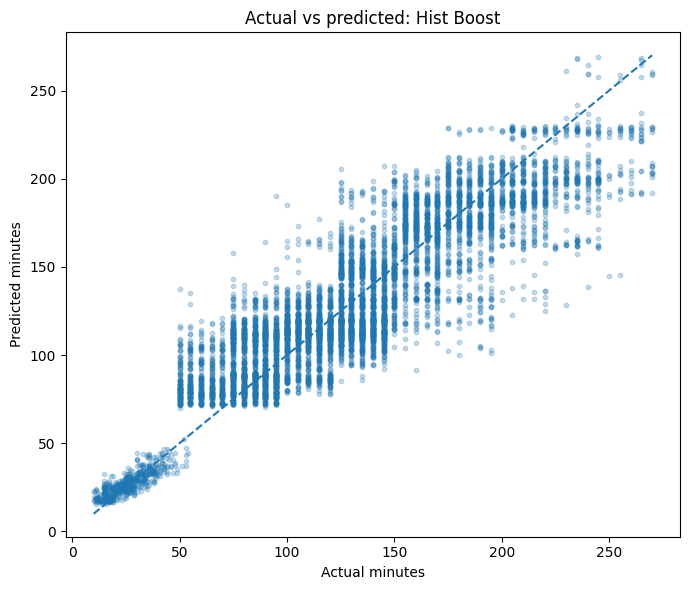

In [10]:
plt.figure(figsize=(7,6))
plt.scatter(pred['Actual_Eval'], pred['Pred_Time'], s=10, alpha=.25)
lo = min(pred['Actual_Eval'].min(), pred['Pred_Time'].min())
hi = max(pred['Actual_Eval'].max(), pred['Pred_Time'].max())
plt.plot([lo,hi],[lo,hi],'--')
plt.xlabel('Actual minutes'); plt.ylabel('Predicted minutes')
plt.title(f'Actual vs predicted: {best_name}')
plt.tight_layout(); plt.show()

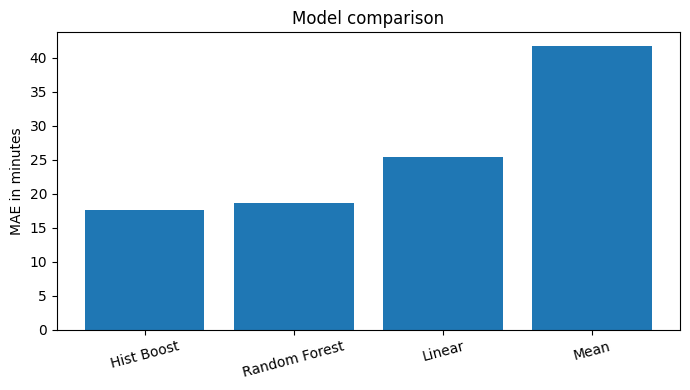

In [11]:
plt.figure(figsize=(7,4))
plt.bar(res['Model'], res['MAE'])
plt.ylabel('MAE in minutes'); plt.title('Model comparison')
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

# Stage 3 — Historical SLA and late-delivery risk

The SLA is the historical 75th percentile of delivery time for similar training orders. A segment needs at least 50 historical observations; otherwise the code falls back to a broader segment and finally the global SLA.

In [12]:
bins = [0,3,7,12,17,np.inf]
labels = ['Very Short','Short','Medium','Long','Very Long']
tr['Dist_Band'] = pd.cut(tr['Dist_km'], bins=bins, labels=labels, include_lowest=True).astype(object)
risk = pred.copy()
risk['Dist_Band'] = pd.cut(risk['Dist_km'], bins=bins, labels=labels, include_lowest=True).astype(object)

q, min_n = .75, 50
global_sla = float(tr[tgt].quantile(q))
levels = [
    ['Dist_Band','Area','Traffic','Vehicle','Category'],
    ['Dist_Band','Area','Traffic','Vehicle'],
    ['Dist_Band','Traffic','Vehicle'],
    ['Dist_Band','Traffic'],
    ['Traffic','Area'],
    ['Traffic']
]

In [13]:
def sla_table(cols):
    z = tr.groupby(cols, dropna=False, observed=True)[tgt].agg(
        Hist_N='size', SLA=lambda x: x.quantile(q)
    ).reset_index()
    return z[z['Hist_N'] >= min_n]

risk['SLA'] = np.nan
risk['SLA_Source'] = pd.NA
risk['SLA_N'] = np.nan

for i, cols in enumerate(levels, 1):
    tab = sla_table(cols).rename(columns={'SLA':f'SLA_{i}','Hist_N':f'N_{i}'})
    risk = risk.merge(tab, on=cols, how='left')
    m = risk['SLA'].isna() & risk[f'SLA_{i}'].notna()
    risk.loc[m,'SLA'] = risk.loc[m,f'SLA_{i}']
    risk.loc[m,'SLA_N'] = risk.loc[m,f'N_{i}']
    risk.loc[m,'SLA_Source'] = f'Level {i}: ' + ' + '.join(cols)
    risk.drop(columns=[f'SLA_{i}',f'N_{i}'], inplace=True)

m = risk['SLA'].isna()
risk.loc[m,'SLA'] = global_sla
risk.loc[m,'SLA_N'] = len(tr)
risk.loc[m,'SLA_Source'] = 'Global'

## 8. Risk classes

- **On-Time:** predicted time is at least one model MAE below the SLA.
- **At Risk:** predicted time lies within one MAE below the SLA.
- **Likely Late:** predicted time exceeds the SLA.

In [14]:
risk['Late_Min'] = np.maximum(0, risk['Pred_Time']-risk['SLA'])
risk['Margin'] = risk['SLA']-risk['Pred_Time']
risk['Risk'] = np.select(
    [risk['Pred_Time'] > risk['SLA'], risk['Pred_Time'] > risk['SLA']-best_mae],
    ['Likely Late','At Risk'], default='On-Time'
)
risk['Risk_Score'] = risk['Risk'].map({'On-Time':0,'At Risk':1,'Likely Late':2})
risk['Actual_Late'] = (risk['Actual_Eval'] > risk['SLA']).astype(int)
risk['Pred_Late'] = (risk['Risk'] == 'Likely Late').astype(int)
risk['Alert'] = risk['Risk'].isin(['At Risk','Likely Late']).astype(int)
risk['Uncertainty'] = best_mae

p = precision_score(risk['Actual_Late'], risk['Pred_Late'], zero_division=0)
r = recall_score(risk['Actual_Late'], risk['Pred_Late'], zero_division=0)
f = f1_score(risk['Actual_Late'], risk['Pred_Late'], zero_division=0)
auc = roc_auc_score(risk['Actual_Late'], risk['Pred_Time']-risk['SLA'])
print({'Precision':round(p,3),'Recall':round(r,3),'F1':round(f,3),'AUC':round(auc,3)})
risk['Risk'].value_counts()

{'Precision': 0.698, 'Recall': 0.632, 'F1': 0.663, 'AUC': np.float64(0.9)}


,count
Risk,
On-Time,5202
Likely Late,1803
At Risk,1743


In [15]:
risk.to_csv(out/'stage3_order_sla_risk.csv', index=False)

risk_sum = risk.groupby('Risk').agg(
    Orders=('Order_ID','size'),
    Mean_Pred=('Pred_Time','mean'),
    Mean_SLA=('SLA','mean'),
    Actual_Late_Rate=('Actual_Late','mean')
).reset_index()
risk_sum['Actual_Late_Rate'] *= 100
risk_sum.to_csv(out/'stage3_risk_summary.csv', index=False)
risk_sum.round(2)

,Risk,Orders,Mean_Pred,Mean_SLA,Actual_Late_Rate
0,At Risk,1743,140.45,149.85,28.92
1,Likely Late,1803,172.43,154.38,69.77
2,On-Time,5202,104.58,156.84,4.38


# Stage 4 — Candidate batching and MILP optimization

Every order receives an individual-delivery option. Nearby and temporally compatible orders may also receive a batch containing up to **3 orders**. Candidate batch times start from the ML prediction and add only incremental waiting and route-detour time, preventing double-counting of the original trip.

Fleet costs, speeds, capacities, and route limits are simulation assumptions because the dataset does not provide them. `max_batch = 3` fully uses the modelled motorcycle capacity while keeping route enumeration computationally manageable.

In [16]:
veh = {
    'Bicycle':    {'cap':1,'speed':15,'fixed':40,'km':2,'max':5},
    'Scooter':    {'cap':2,'speed':25,'fixed':55,'km':4,'max':18},
    'Motorcycle': {'cap':3,'speed':30,'fixed':65,'km':5,'max':35},
    'Van':        {'cap':6,'speed':22,'fixed':100,'km':12,'max':np.inf}
}
traf = {'Low':1.0,'Medium':1.2,'High':1.5,'Jam':1.8}
win, max_store, max_drop = 20, 1.0, 3.0
pickup_stop, drop_stop, late_cost = 2, 3, 5
max_batch = 3

## 9. Vehicle-specific predictions

Because vehicle type is a model feature, the notebook predicts the standalone time for every feasible candidate vehicle before evaluating routes.

In [17]:
risk['Order_Hour'] = risk['Order_Min']/60
risk['Age_U18'] = (risk['Agent_Age'] < 18).astype(int)
risk['Dist_Miss'] = risk['Dist_km'].isna().astype(int)
risk['Weekend'] = pd.to_datetime(risk['Order_Date']).dt.dayofweek.isin([5,6]).astype(int)
risk['Peak'] = (risk['Order_Hour'].between(12,14) | risk['Order_Hour'].between(18,21)).astype(int)
risk['Geo_OK'] = risk['Geo_OK'].astype(int)

for v in veh:
    z = risk[feat].copy()
    z['Vehicle'] = v
    risk[f'ML_{v}'] = best_pipe.predict(z)

## 10. Individual candidates

Orders without valid coordinates remain fixed individual deliveries. Valid orders enter the optimization, and their cheapest feasible individual vehicle becomes the guaranteed fallback candidate.

In [18]:
ok = risk['Geo_OK'].eq(1) & risk['Dist_km'].notna() & risk['Pickup_Min'].notna() & risk['Order_Min'].notna() & risk['SLA'].notna() & risk['Order_Date'].notna()
opt, fixed = risk[ok].copy(), risk[~ok].copy()
opt['Day'] = pd.to_datetime(opt['Order_Date']).dt.strftime('%Y-%m-%d')
opt['Window'] = (opt['Order_Min']//win).astype(int)

def cost(dist, v, late):
    s = veh[v]
    return s['fixed'] + dist*s['km'] + late*late_cost

singles = []
for _, o in opt.iterrows():
    choices = []
    for v, s in veh.items():
        dist = float(o['Dist_km'])
        if dist > s['max']:
            continue
        pt = float(o[f'ML_{v}'])
        late = max(0, pt-o['SLA'])
        choices.append({
            'CID':f"S_{o['Order_ID']}_{v}", 'Type':'Individual',
            'Orders':(o['Order_ID'],), 'Size':1, 'Vehicle':v,
            'Route':f"S{o['Order_ID']} → D{o['Order_ID']}",
            'Distance':dist, 'Time_1':pt, 'Time_2':np.nan,
            'Late_1':late, 'Late_2':np.nan, 'Cost':cost(dist,v,late)
        })
    singles.append(min(choices, key=lambda x:x['Cost']))

single_df = pd.DataFrame(singles)
single_cost = {x['Orders'][0]:x['Cost'] for x in singles}
print('Optimizable:', len(opt), '| Fixed:', len(fixed))

Optimizable: 8186 | Fixed: 562


## 11. Two- and three-order batch evaluation

Candidate batches must be in the same 20-minute window, have every pair of stores within 1 km, every pair of customers within 3 km, and contain no order already classified as Likely Late.

For a batch of size $r$, the notebook evaluates $r!$ pickup orders and $r!$ drop orders. Therefore, it evaluates 4 sequences for two orders and 36 sequences for three orders.

In [19]:
def farthest(b, lat, lon):
    ds = [float(hav(b[i][lat], b[i][lon], b[j][lat], b[j][lon]))
          for i, j in combinations(range(len(b)), 2)]
    return max(ds, default=0)


def eval_batch(b, po, do, v):
    s = veh[v]
    pts = {}
    for i, o in enumerate(b):
        pts[f'S{i}'] = (o['Store_Latitude'], o['Store_Longitude'])
        pts[f'D{i}'] = (o['Drop_Latitude'], o['Drop_Longitude'])

    route = [f'S{i}' for i in po] + [f'D{i}' for i in do]
    mult = max(traf.get(o['Traffic'], 1.2) for o in b)
    dist, t = 0.0, 0.0
    arr = {route[0]: 0.0}

    for k in range(1, len(route)):
        p1, p2 = pts[route[k-1]], pts[route[k]]
        leg = float(hav(p1[0], p1[1], p2[0], p2[1]))
        dist += leg
        t += leg * 60 * mult / s['speed']
        arr[route[k]] = t
        if route[k].startswith('S') and k < len(route)-1:
            t += pickup_stop
        if route[k].startswith('D') and k < len(route)-1:
            t += drop_stop

    dispatch = max(o['Pickup_Min'] for o in b)
    times, lates = [], []

    for i, o in enumerate(b):
        tm = traf.get(o['Traffic'], 1.2)
        direct = o['Dist_km'] * 60 * tm / s['speed']
        wait = max(0, dispatch - o['Pickup_Min'])
        extra = max(0, arr[f'D{i}'] - direct)
        pt = float(o[f'ML_{v}']) + wait + extra
        times.append(pt)
        lates.append(max(0, pt - o['SLA']))

    return dist, times, lates, route

In [20]:
batches = []
pool = opt[opt['Risk'] != 'Likely Late']

for _, g in pool.groupby(['Day','Window']):
    rows = [o for _, o in g.iterrows()]
    n = len(rows)
    edge = {}
    adj = [set() for _ in range(n)]

    for i, j in combinations(range(n), 2):
        if abs(rows[i]['Order_Min'] - rows[j]['Order_Min']) > win:
            continue
        sd = float(hav(rows[i]['Store_Latitude'], rows[i]['Store_Longitude'],
                       rows[j]['Store_Latitude'], rows[j]['Store_Longitude']))
        dd = float(hav(rows[i]['Drop_Latitude'], rows[i]['Drop_Longitude'],
                       rows[j]['Drop_Latitude'], rows[j]['Drop_Longitude']))
        if sd <= max_store and dd <= max_drop:
            edge[(i,j)] = (sd,dd)
            adj[i].add(j)
            adj[j].add(i)

    groups = [(2, (i,j), sd, dd) for (i,j), (sd,dd) in edge.items()]

    if max_batch >= 3:
        for i in range(n):
            for j in sorted(x for x in adj[i] if x > i):
                for k in sorted(x for x in adj[i].intersection(adj[j]) if x > j):
                    e = [edge[tuple(sorted(x))] for x in [(i,j),(i,k),(j,k)]]
                    groups.append((3, (i,j,k), max(x[0] for x in e), max(x[1] for x in e)))

    for size, ids0, sd, dd in groups:
        b = [rows[i] for i in ids0]
        choices = []

        for v, s in veh.items():
            if s['cap'] < size:
                continue

            for po in permutations(range(size)):
                for do in permutations(range(size)):
                    dist, ts, ls, route = eval_batch(b, po, do, v)

                    if dist > s['max']:
                        continue
                    if any(ts[i] > b[i]['SLA'] + best_mae for i in range(size)):
                        continue

                    c = cost(dist, v, sum(ls))
                    sep = sum(single_cost[o['Order_ID']] for o in b)
                    if c >= sep:
                        continue

                    x = {
                        'CID':'B_'+'_'.join(str(o['Order_ID']) for o in b)+f'_{v}',
                        'Type':f'Batch-{size}',
                        'Orders':tuple(o['Order_ID'] for o in b),
                        'Size':size, 'Vehicle':v, 'Route':' → '.join(route),
                        'Distance':dist, 'Cost':c, 'Saving':sep-c,
                        'Store_Dist':sd, 'Drop_Dist':dd
                    }
                    for j in range(size):
                        x[f'Time_{j+1}'] = ts[j]
                        x[f'Late_{j+1}'] = ls[j]
                    choices.append(x)

        if choices:
            batches.append(min(choices, key=lambda x:x['Cost']))

batch_df = pd.DataFrame(batches)
print('Feasible batches:', len(batch_df))
if len(batch_df):
    print(batch_df['Size'].value_counts().sort_index())

Feasible batches: 587
Size
2    552
3     35
Name: count, dtype: int64


## 12. Set-partitioning MILP

Each candidate has a binary decision variable. The objective minimizes simulated fixed, travel, and lateness cost. Every optimizable order must be covered exactly once.

In [21]:
cands = pd.concat([single_df, batch_df], ignore_index=True, sort=False) if len(batch_df) else single_df.copy()
ids = opt['Order_ID'].astype(str).tolist()
row = {x:i for i,x in enumerate(ids)}
rr, cc, vv = [], [], []
for j, orders in enumerate(cands['Orders']):
    for x in orders:
        rr.append(row[str(x)]); cc.append(j); vv.append(1)

A = coo_matrix((vv,(rr,cc)), shape=(len(ids),len(cands))).tocsr()
con = LinearConstraint(A, np.ones(len(ids)), np.ones(len(ids)))
sol = milp(
    c=cands['Cost'].to_numpy(float),
    integrality=np.ones(len(cands),int),
    bounds=Bounds(np.zeros(len(cands)),np.ones(len(cands))),
    constraints=con,
    options={'time_limit':120,'mip_rel_gap':0.0}
)
if sol.x is None:
    raise RuntimeError(sol.message)

cands['Selected'] = (sol.x > .5).astype(int)
sel = cands[cands['Selected'].eq(1)].copy()
print(sol.message)
sel['Size'].value_counts().sort_index()

Optimization terminated successfully. (HiGHS Status 7: Optimal)


,count
Size,
1,7250
2,438
3,20


## 13. Order assignments and policy comparison

The selected candidate table is expanded so that each order has one trip, vehicle, route, optimized prediction, and predicted late-minute value. Reported savings are simulated, not real Amazon financial results.

In [22]:
rows = []
for _, c in sel.iterrows():
    for j, oid in enumerate(c['Orders'],1):
        rows.append({
            'Order_ID':oid, 'CID':c['CID'], 'Type':c['Type'],
            'Vehicle':c['Vehicle'], 'Route':c['Route'], 'Batch_Size':c['Size'],
            'Route_km':c['Distance'], 'Trip_Cost':c['Cost'],
            'Opt_Time':c[f'Time_{j}'], 'Opt_Late_Min':c[f'Late_{j}']
        })
assign = pd.DataFrame(rows)

fixed_rows = pd.DataFrame({
    'Order_ID':fixed['Order_ID'], 'CID':'FIXED_'+fixed['Order_ID'].astype(str),
    'Type':'Fixed Individual', 'Vehicle':fixed['Vehicle'], 'Route':'Not optimized',
    'Batch_Size':1, 'Route_km':fixed['Dist_km'], 'Trip_Cost':np.nan,
    'Opt_Time':fixed['Pred_Time'], 'Opt_Late_Min':fixed['Late_Min']
})
assign_all = pd.concat([assign,fixed_rows], ignore_index=True)
assert assign_all['Order_ID'].nunique() == len(risk)

In [23]:
base_trips = len(opt)
opt_trips = len(sel)
base_cost = single_df['Cost'].sum()
opt_cost = sel['Cost'].sum()
base_dist = single_df['Distance'].sum()
opt_dist = sel['Distance'].sum()
batch2 = int((sel['Size']==2).sum())
batch3 = int((sel['Size']==3).sum())
batched_orders = int(sel.loc[sel['Size']>1, 'Size'].sum())

summary = pd.DataFrame({
    'Metric':['Optimized orders','Baseline trips','Optimized trips',
              'Selected 2-order batches','Selected 3-order batches','Orders batched',
              'Trip reduction %','Baseline distance km','Optimized distance km',
              'Distance reduction %','Baseline simulated cost','Optimized simulated cost',
              'Cost reduction %'],
    'Value':[len(opt),base_trips,opt_trips,batch2,batch3,batched_orders,
             100*(base_trips-opt_trips)/base_trips,base_dist,opt_dist,
             100*(base_dist-opt_dist)/base_dist,base_cost,opt_cost,
             100*(base_cost-opt_cost)/base_cost]
})
summary.round(3)

,Metric,Value
0,Optimized orders,8186.000
1,Baseline trips,8186.000
2,Optimized trips,7708.000
3,Selected 2-order batches,438.000
4,Selected 3-order batches,20.000
5,Orders batched,936.000
6,Trip reduction %,5.839
7,Baseline distance km,82193.265
8,Optimized distance km,78279.724
9,Distance reduction %,4.761


In [24]:
exp = cands.copy()
exp['Orders'] = exp['Orders'].apply(lambda x:'|'.join(map(str,x)))
sel_exp = sel.copy()
sel_exp['Orders'] = sel_exp['Orders'].apply(lambda x:'|'.join(map(str,x)))

exp.to_csv(out/'stage4_all_candidates.csv', index=False)
sel_exp.to_csv(out/'stage4_selected_candidates.csv', index=False)
assign_all.to_csv(out/'stage4_order_assignments.csv', index=False)
summary.to_csv(out/'stage4_policy_summary.csv', index=False)

print('Outputs saved in:', out.resolve())

Outputs saved in: /content/delivery_outputs_max3


## 14. Final workflow

The final pipeline is:

**Clean data → KNN preprocessing → delivery-time prediction → historical SLA → late-risk class → safe 2–3 order batches → MILP trip selection**

The optimization uses predicted time through vehicle-specific baseline times, batch-adjusted times, SLA feasibility constraints, and late-minute penalties. Actual test delivery time is retained only for evaluation and never enters the optimization objective.

With `max_batch = 3`, the notebook evaluates single deliveries, two-order batches, and three-order batches. The MILP still assigns every optimizable order exactly once.

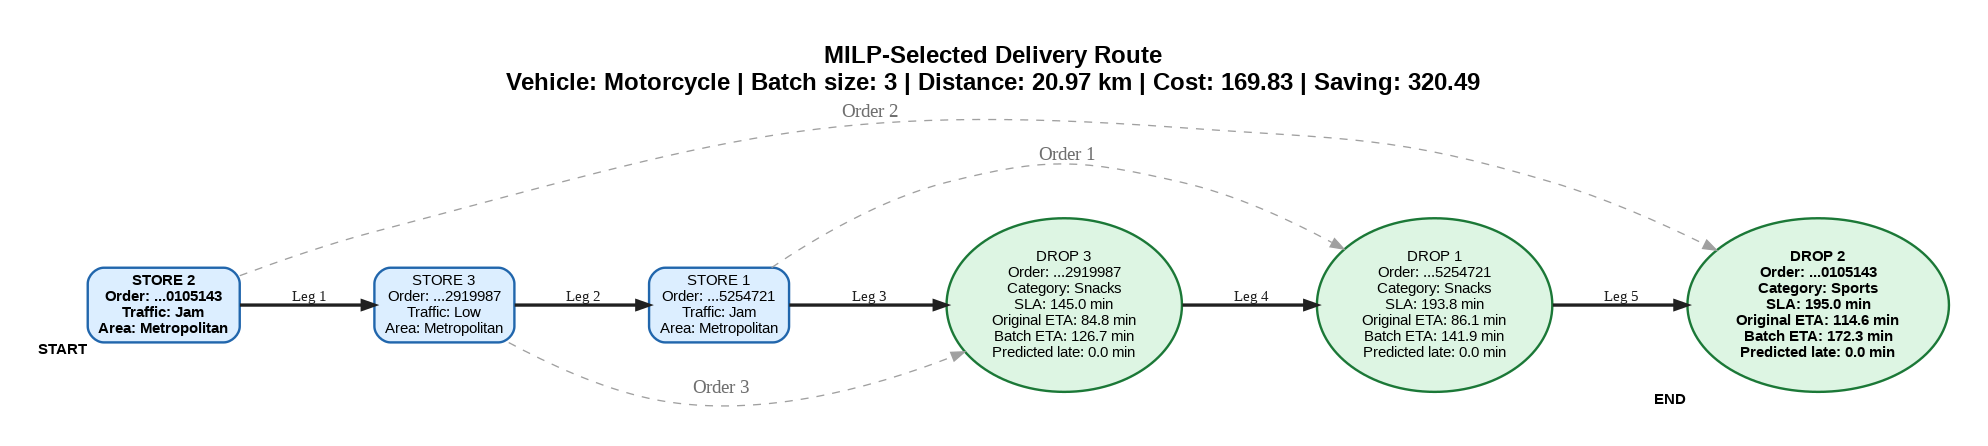

Candidate ID: B_dyqk725254721_tkoz270105143_pcza532919987_Motorcycle
Orders: dyqk725254721|tkoz270105143|pcza532919987
Route: S1 → S2 → S0 → D2 → D0 → D1
Vehicle: Motorcycle
Distance: 20.97 km
Saving: 320.49

PNG saved at: /mnt/data/graphviz_routes/highest_saving_three_order_route.png
PDF saved at: /mnt/data/graphviz_routes/highest_saving_three_order_route.pdf
SVG saved at: /mnt/data/graphviz_routes/highest_saving_three_order_route.svg


In [27]:
from pathlib import Path

import pandas as pd
from graphviz import Digraph
from IPython.display import Image, display


# ---------------------------------------------------
# 1. File paths
# ---------------------------------------------------
BASE = Path("/content/delivery_outputs_max3")

SELECTED_FILE = BASE / "stage4_selected_candidates.csv"
ORDER_FILE = BASE / "stage3_order_sla_risk.csv"

OUTPUT_DIR = Path("/mnt/data/graphviz_routes")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------
# 2. Load MILP results and order information
# ---------------------------------------------------
selected = pd.read_csv(SELECTED_FILE)
orders = pd.read_csv(ORDER_FILE)


# ---------------------------------------------------
# 3. Helper functions
# ---------------------------------------------------
def parse_orders(value):
    """
    Converts:
        order_1|order_2|order_3

    into:
        ['order_1', 'order_2', 'order_3']
    """
    return [
        x.strip()
        for x in str(value).split("|")
        if x.strip()
    ]


def parse_route(value):
    """
    Converts:
        S1 → S2 → S0 → D2 → D0 → D1

    into:
        ['S1', 'S2', 'S0', 'D2', 'D0', 'D1']
    """
    value = str(value).replace("->", "→")

    return [
        x.strip()
        for x in value.split("→")
        if x.strip()
    ]


def safe_value(row, column, default="NA"):
    """
    Safely obtains a dataframe value.
    """
    if column not in row.index:
        return default

    value = row[column]

    if pd.isna(value):
        return default

    return value


# ---------------------------------------------------
# 4. Select one MILP candidate
# ---------------------------------------------------
def select_candidate(selected_df, batch_size=3, candidate_id=None):
    """
    Selects either:
    1. A candidate using its CID, or
    2. The highest-saving candidate of a specified size.
    """

    if candidate_id is not None:
        result = selected_df[
            selected_df["CID"].astype(str) == str(candidate_id)
        ]

        if result.empty:
            raise ValueError(
                f"No selected candidate found with CID={candidate_id}"
            )

        return result.iloc[0]

    result = selected_df[
        selected_df["Size"] == batch_size
    ].copy()

    if result.empty:
        raise ValueError(
            f"No selected batch of size {batch_size} was found."
        )

    if "Saving" in result.columns:
        result = result.sort_values(
            "Saving",
            ascending=False
        )

    return result.iloc[0]


# ---------------------------------------------------
# 5. Create Graphviz route
# ---------------------------------------------------
def create_route_graph(
    candidate,
    order_df,
    output_name="milp_selected_route"
):
    """
    Creates a Graphviz diagram for one selected MILP trip.
    """

    order_ids = parse_orders(candidate["Orders"])
    route = parse_route(candidate["Route"])

    order_lookup = (
        order_df
        .drop_duplicates("Order_ID")
        .set_index("Order_ID")
    )

    missing_ids = [
        oid for oid in order_ids
        if oid not in order_lookup.index
    ]

    if missing_ids:
        raise ValueError(
            f"Order information not found for: {missing_ids}"
        )

    batch_orders = order_lookup.loc[order_ids].copy()

    graph = Digraph(
        name="MILP_Route",
        format="png"
    )

    # Overall graph layout
    graph.attr(
        rankdir="LR",
        splines="spline",
        nodesep="0.75",
        ranksep="1.0",
        pad="0.4",
        bgcolor="white"
    )

    vehicle = safe_value(candidate, "Vehicle")
    distance = safe_value(candidate, "Distance")
    saving = safe_value(candidate, "Saving", 0)
    cost = safe_value(candidate, "Cost")

    title = (
        "MILP-Selected Delivery Route"
        f"\nVehicle: {vehicle}"
        f" | Batch size: {len(order_ids)}"
        f" | Distance: {float(distance):.2f} km"
        f" | Cost: {float(cost):.2f}"
        f" | Saving: {float(saving):.2f}"
    )

    graph.attr(
        label=title,
        labelloc="t",
        fontsize="18",
        fontname="Helvetica-Bold"
    )

    # ---------------------------------------------------
    # Create one store and one destination node per order
    # ---------------------------------------------------
    for i, order_id in enumerate(order_ids):

        row = batch_orders.loc[order_id]

        short_id = (
            str(order_id)
            if len(str(order_id)) <= 10
            else "..." + str(order_id)[-7:]
        )

        traffic = safe_value(row, "Traffic")
        area = safe_value(row, "Area")
        category = safe_value(row, "Category")
        sla = safe_value(row, "SLA")
        original_prediction = safe_value(
            row,
            "Pred_Time"
        )

        time_column = f"Time_{i + 1}"
        late_column = f"Late_{i + 1}"

        optimized_time = safe_value(
            candidate,
            time_column
        )

        late_minutes = safe_value(
            candidate,
            late_column,
            0
        )

        # Store node
        store_label = (
            f"STORE {i + 1}"
            f"\nOrder: {short_id}"
            f"\nTraffic: {traffic}"
            f"\nArea: {area}"
        )

        graph.node(
            f"S{i}",
            label=store_label,
            shape="box",
            style="rounded,filled",
            fillcolor="#DCEEFF",
            color="#2166AC",
            fontname="Helvetica",
            fontsize="11",
            penwidth="1.8"
        )

        # Destination node
        drop_label = (
            f"DROP {i + 1}"
            f"\nOrder: {short_id}"
            f"\nCategory: {category}"
            f"\nSLA: {float(sla):.1f} min"
            f"\nOriginal ETA: "
            f"{float(original_prediction):.1f} min"
            f"\nBatch ETA: "
            f"{float(optimized_time):.1f} min"
            f"\nPredicted late: "
            f"{float(late_minutes):.1f} min"
        )

        # Mark late destinations differently
        if float(late_minutes) > 0:
            drop_fill = "#FFD9D9"
            drop_border = "#B2182B"
        else:
            drop_fill = "#DDF5E3"
            drop_border = "#1B7837"

        graph.node(
            f"D{i}",
            label=drop_label,
            shape="ellipse",
            style="filled",
            fillcolor=drop_fill,
            color=drop_border,
            fontname="Helvetica",
            fontsize="11",
            penwidth="1.8"
        )

        # Dashed relationship between store and its order drop
        graph.edge(
            f"S{i}",
            f"D{i}",
            label=f" Order {i + 1}",
            style="dashed",
            color="#A0A0A0",
            fontcolor="#707070",
            constraint="false"
        )

    # ---------------------------------------------------
    # Draw the actual MILP-selected sequence
    # ---------------------------------------------------
    for step in range(len(route) - 1):

        current_node = route[step]
        next_node = route[step + 1]

        graph.edge(
            current_node,
            next_node,
            label=f" Leg {step + 1}",
            color="#202020",
            fontcolor="#202020",
            fontsize="11",
            penwidth="2.5",
            arrowsize="0.9"
        )

    # Highlight the first node
    if route:
        graph.node(
            route[0],
            xlabel="START",
            fontname="Helvetica-Bold"
        )

        graph.node(
            route[-1],
            xlabel="END",
            fontname="Helvetica-Bold"
        )

    # ---------------------------------------------------
    # Save the graph
    # ---------------------------------------------------
    png_path = graph.render(
        filename=output_name,
        directory=str(OUTPUT_DIR),
        format="png",
        cleanup=True
    )

    pdf_path = graph.render(
        filename=output_name,
        directory=str(OUTPUT_DIR),
        format="pdf",
        cleanup=True
    )

    svg_path = graph.render(
        filename=output_name,
        directory=str(OUTPUT_DIR),
        format="svg",
        cleanup=True
    )

    return graph, png_path, pdf_path, svg_path


# ---------------------------------------------------
# 6. Select highest-saving three-order batch
# ---------------------------------------------------
candidate = select_candidate(
    selected_df=selected,
    batch_size=3
)


# ---------------------------------------------------
# 7. Generate and display graph
# ---------------------------------------------------
graph, png_path, pdf_path, svg_path = create_route_graph(
    candidate=candidate,
    order_df=orders,
    output_name="highest_saving_three_order_route"
)

display(Image(filename=png_path))

print("Candidate ID:", candidate["CID"])
print("Orders:", candidate["Orders"])
print("Route:", candidate["Route"])
print("Vehicle:", candidate["Vehicle"])
print("Distance:", round(candidate["Distance"], 2), "km")
print("Saving:", round(candidate["Saving"], 2))

print("\nPNG saved at:", png_path)
print("PDF saved at:", pdf_path)
print("SVG saved at:", svg_path)